In [1]:
import numpy as np
import pandas as pd 
import os


In [2]:
import sys
print(sys.executable)

c:\Users\khamb\OneDrive\Desktop\aifolder\Heavy_Equipment_\Scripts\python.exe


In [3]:
trainData = pd.read_csv("../train.csv",low_memory=False)
testData = pd.read_csv("../test.csv",low_memory=False)


# Data Exploration & Visualization

In [4]:
trainData.info()

<class 'pandas.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  str    
 5   VendorPartnerID            138701 non-null  str    
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   str    
 9   TransactionDate            138701 non-null  str    
 10  Spec_FullDescriptor        138701 non-null  str    
 11  Spec_BaseClass             138701 non-null  str    
 12  Spec_SubClass              101716 non-null  str    
 13  Spec_ReleaseSeries         32896 non-nul

In [5]:
trainData.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,NaN,NaN,NaN,2186275.950556,1128496.619347,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,NaN,NaN,NaN,41521.874047,26361.125948,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,NaN,NaN,NaN,1204814.320423,528737.593449,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,NaN,NaN,NaN,7286.421922,7542.421537,39.0,1693.0,3852.0,11873.0,37209.0
DataOriginCode,138701,6,ADI149,59541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VendorPartnerID,138701,31,UJF,67828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ManufactureYear,138701.0,NaN,NaN,NaN,1891.640853,306.992001,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,NaN,NaN,NaN,4553.718943,27922.04485,0.0,0.0,1620.0,5001.0,1729600.0
UtilizationTier,50475,3,Medium,24588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,138701,3676,2010-02-16,1159,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
trainData.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [7]:
trainData.nunique()

TransactionID                138701
TargetValue                     675
AssetID                      120111
ProductConfigID                3594
DataOriginCode                    6
VendorPartnerID                  31
ManufactureYear                  68
OperationalHoursMeter         14643
UtilizationTier                   3
TransactionDate                3676
Spec_FullDescriptor            3505
Spec_BaseClass                 1249
Spec_SubClass                   147
Spec_ReleaseSeries              113
Spec_VariantModifier            132
AssetScaleFactor                  6
FunctionalClassification         65
RegionCode                       53
InventoryGroupCategory            6
InventoryGroupDescription         6
col1                              4
CabinType                         3
Forks                             2
col3                              3
col4                              2
DrivetrainType                    8
col5                              2
col6                        

In [8]:
trainData.isna().mean()*100

TransactionID                 0.000000
TargetValue                   0.000000
AssetID                       0.000000
ProductConfigID               0.000000
DataOriginCode                0.000000
VendorPartnerID               0.000000
ManufactureYear               0.000000
OperationalHoursMeter        40.838206
UtilizationTier              63.608770
TransactionDate               0.000000
Spec_FullDescriptor           0.000000
Spec_BaseClass                0.000000
Spec_SubClass                26.665273
Spec_ReleaseSeries           76.282795
Spec_VariantModifier         62.269919
AssetScaleFactor             29.711394
FunctionalClassification      0.000000
RegionCode                    0.000000
InventoryGroupCategory        0.000000
InventoryGroupDescription     0.000000
col1                         75.641127
CabinType                     0.000000
Forks                        78.861724
col3                         78.909309
col4                         92.515555
DrivetrainType           

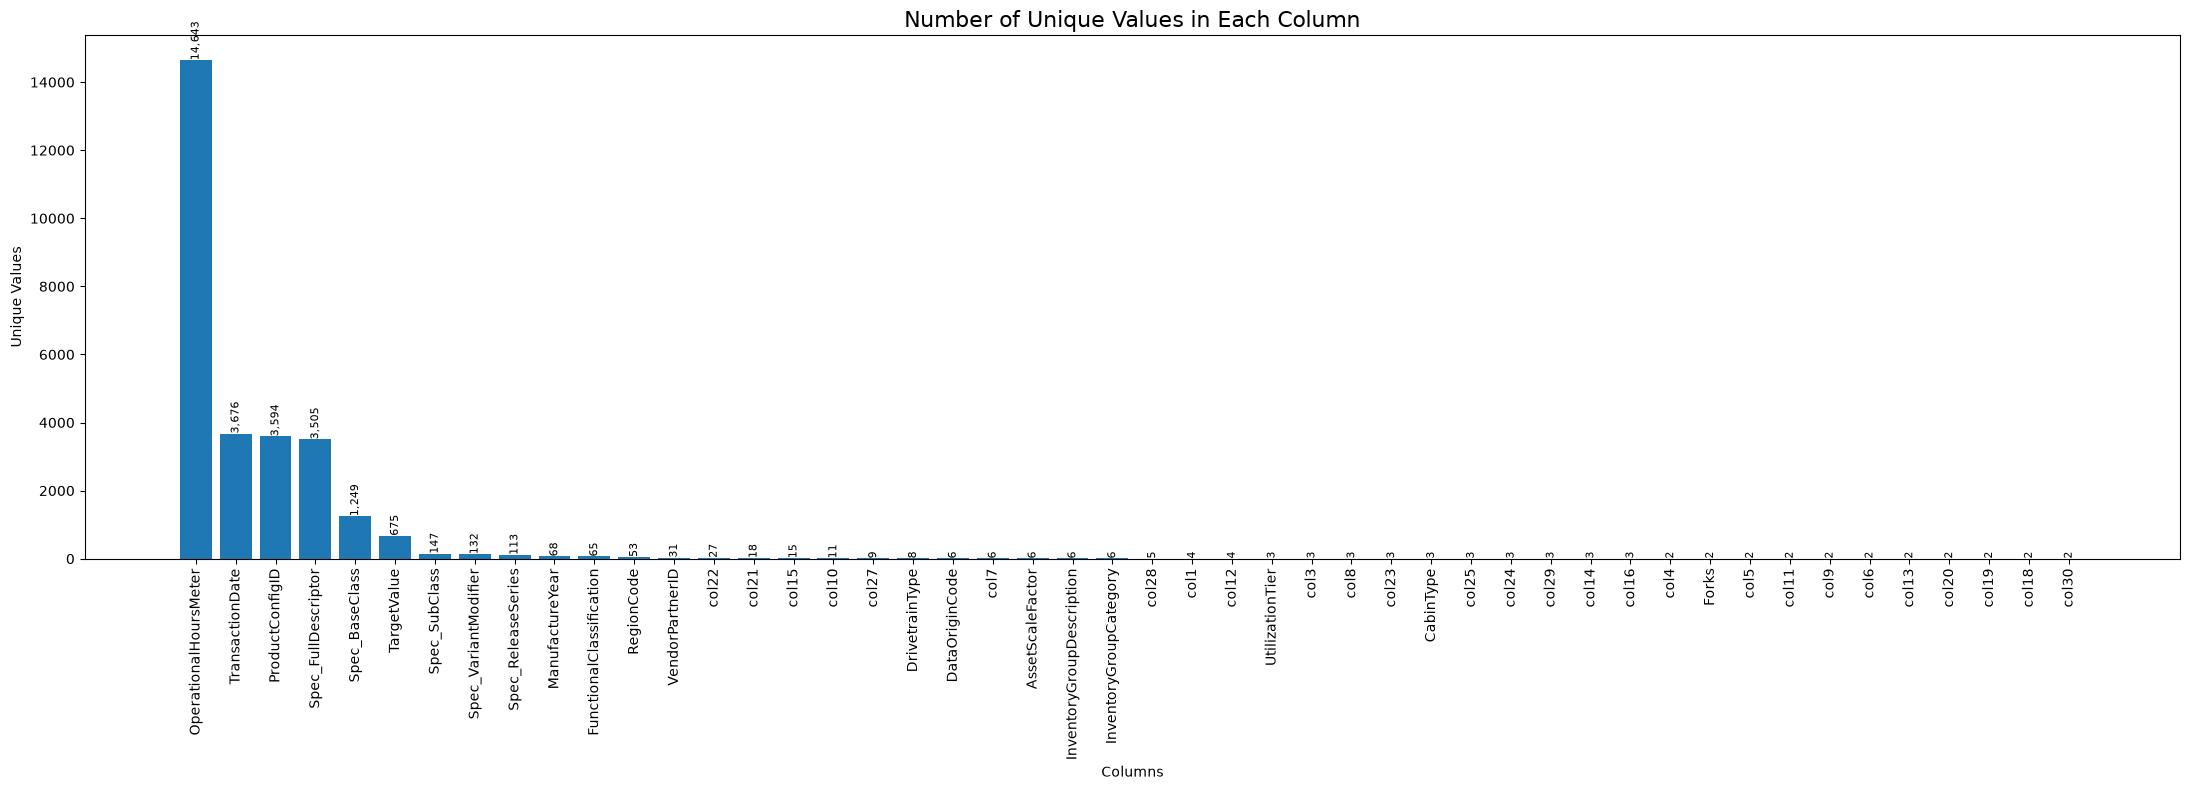

In [9]:
import matplotlib.pyplot as plt

unique_counts = trainData.nunique()

unique_counts = unique_counts.drop(["TransactionID", "AssetID"])

unique_counts = unique_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(22, 8))

bars = ax.bar(unique_counts.index, unique_counts.values)

ax.set_title("Number of Unique Values in Each Column", fontsize=16)
ax.set_xlabel("Columns")
ax.set_ylabel("Unique Values")

plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=8
    )

plt.tight_layout()
plt.show()

C:\Users\khamb\AppData\Local\Temp\ipykernel_25684\3855549158.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in trainData.select_dtypes(include="object"):


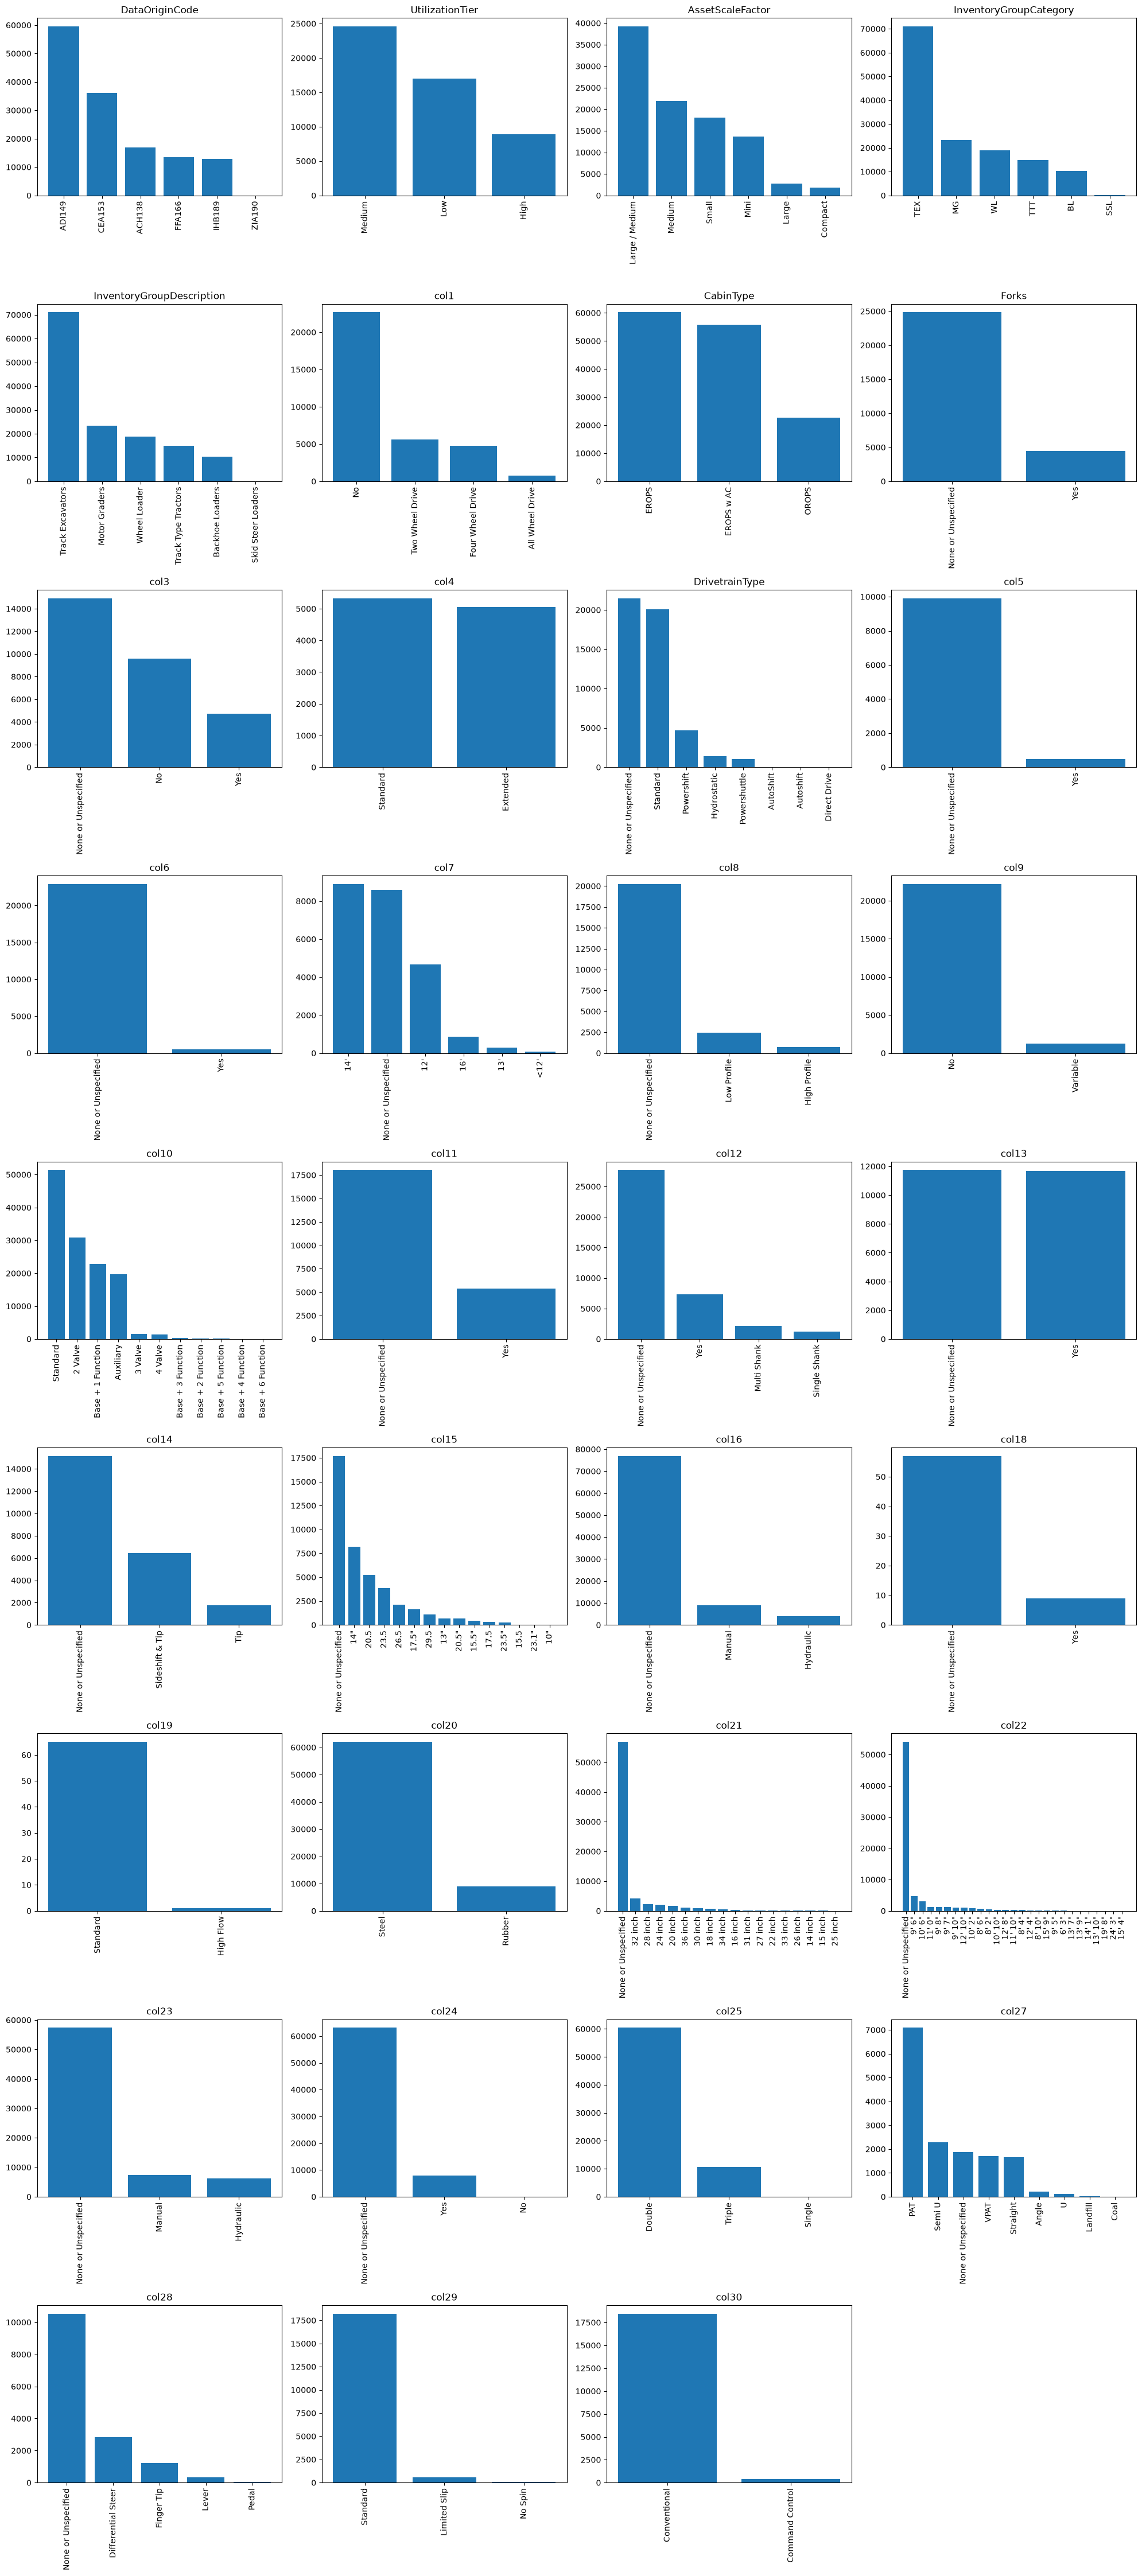

In [10]:
categorical_cols = []

for col in trainData.select_dtypes(include="object"):
    if trainData[col].nunique() <= 30:
        categorical_cols.append(col)

rows = (len(categorical_cols) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = trainData[col].value_counts()

    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=90)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

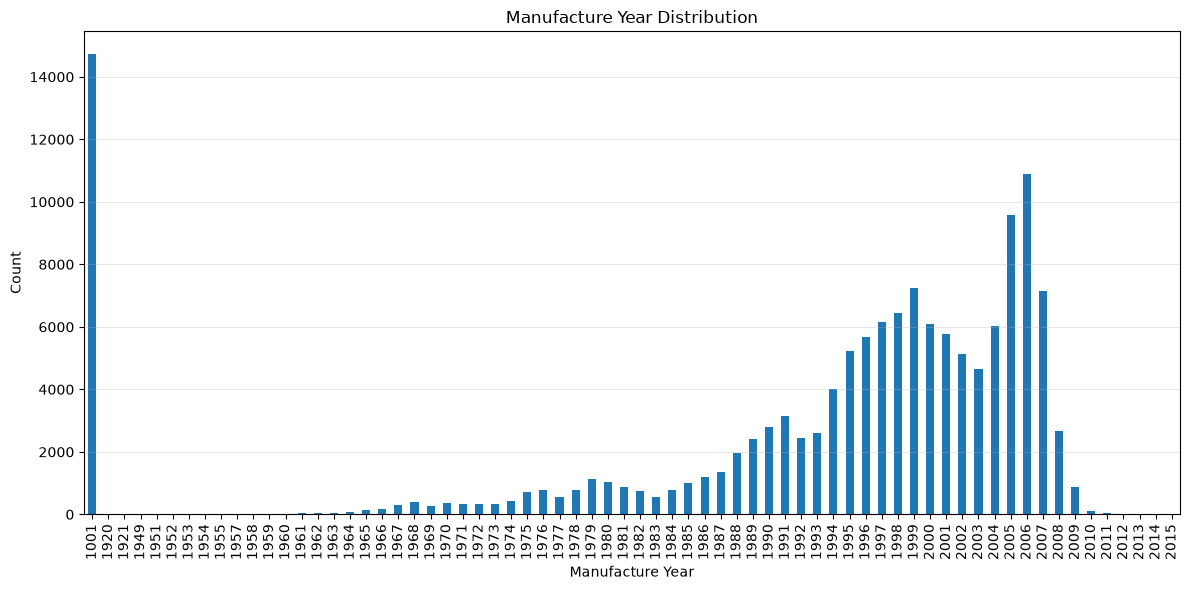

In [11]:
year_counts = trainData["ManufactureYear"].value_counts().sort_index()

ax = year_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Manufacture Year Distribution")
ax.set_xlabel("Manufacture Year")
ax.set_ylabel("Count")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

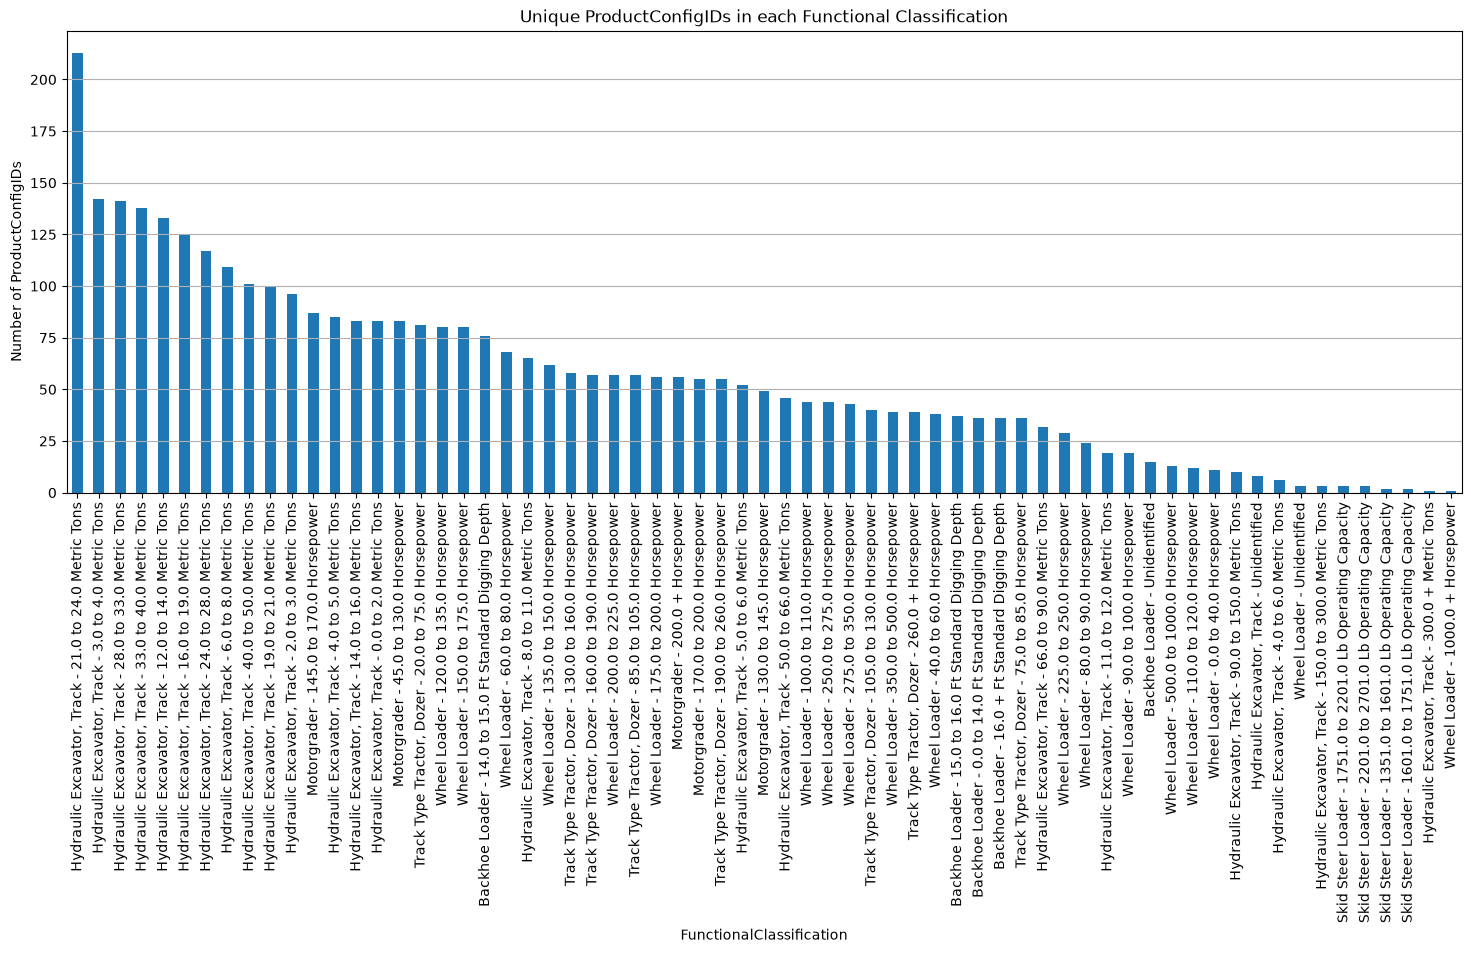

In [12]:
fc_product = (
    trainData.groupby("FunctionalClassification")["ProductConfigID"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(18,6))
fc_product.plot(kind="bar")
plt.title("Unique ProductConfigIDs in each Functional Classification")
plt.ylabel("Number of ProductConfigIDs")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

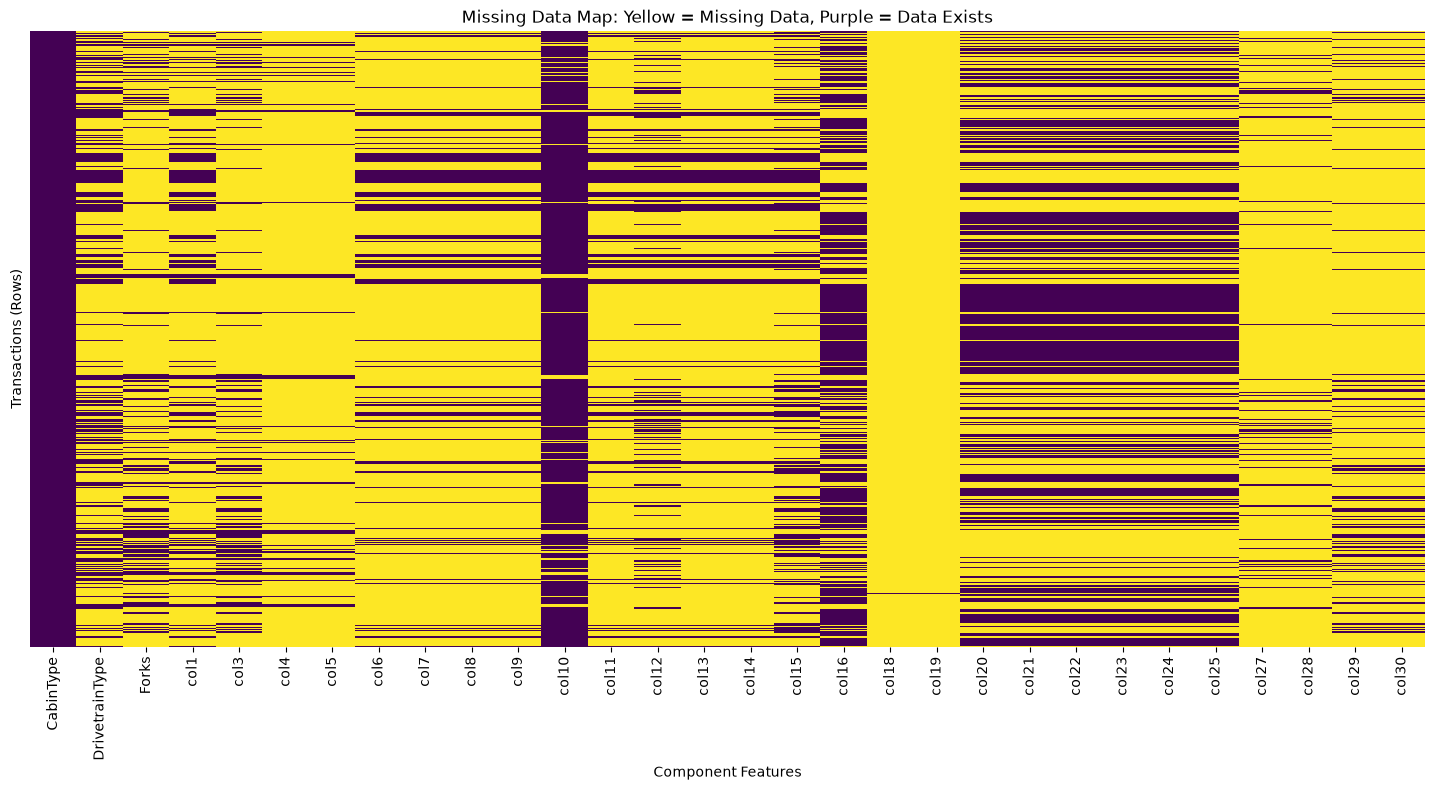

In [13]:
import seaborn as sns
component_columns = ['CabinType', 'DrivetrainType', 'Forks'] + [col for col in trainData.columns if col.startswith('col')]


missing_data_matrix = trainData[component_columns].isnull()


plt.figure(figsize=(18, 8))

sns.heatmap(missing_data_matrix, cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Data Map: Yellow = Missing Data, Purple = Data Exists')
plt.xlabel('Component Features')
plt.ylabel('Transactions (Rows)')
plt.show()

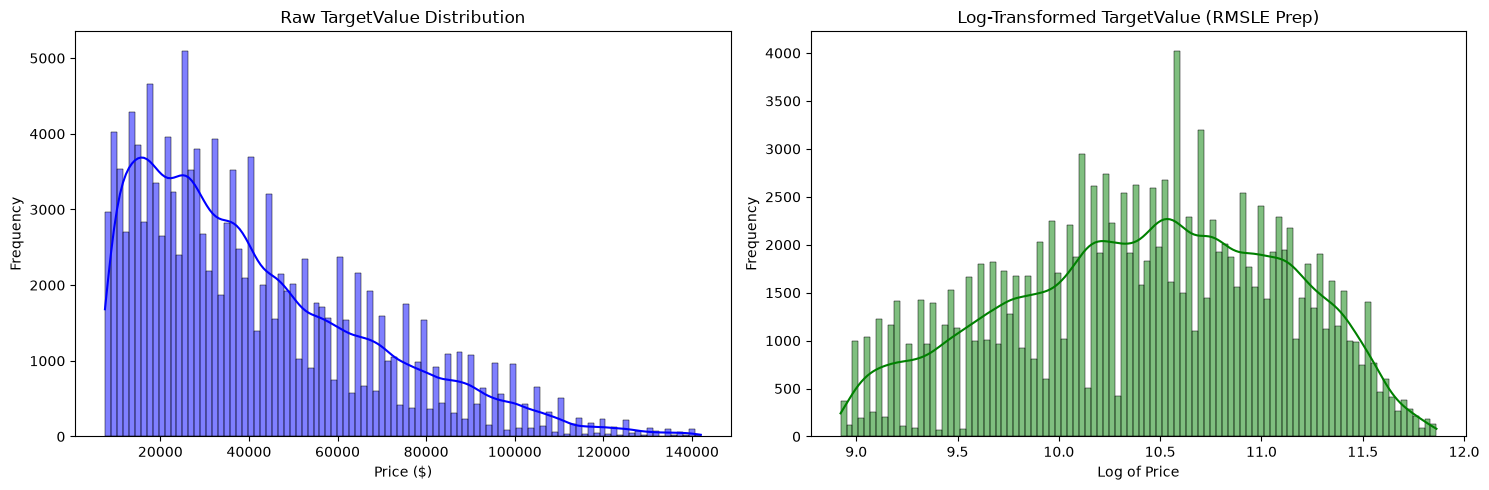

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.histplot(trainData['TargetValue'], bins=100, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Raw TargetValue Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')


sns.histplot(np.log1p(trainData['TargetValue']), bins=100, kde=True, ax=axes[1], color='green')
axes[1].set_title('Log-Transformed TargetValue (RMSLE Prep)')
axes[1].set_xlabel('Log of Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [15]:
metadata = pd.DataFrame({
    'dtype': trainData.dtypes.astype(str),
    'nulls': trainData.isnull().sum(),
    'null_pct': (trainData.isnull().mean() * 100).round(2),
    'unique': trainData.nunique(),
    'sample_value': trainData.iloc[0]
})
metadata

,dtype,nulls,null_pct,unique,sample_value
TransactionID,int64,0,0.00,138701,1139309
TargetValue,float64,0,0.00,675,57000.0
AssetID,int64,0,0.00,120111,117665
ProductConfigID,int64,0,0.00,3594,88
DataOriginCode,str,0,0.00,6,ACH138
VendorPartnerID,str,0,0.00,31,GTX
ManufactureYear,int64,0,0.00,68,1997
OperationalHoursMeter,float64,56643,40.84,14643,4640.0
UtilizationTier,str,88226,63.61,3,Low
TransactionDate,str,0,0.00,3676,2005-03-26


In [16]:

component_columns = ['CabinType', 'DrivetrainType', 'Forks'] + [col for col in trainData.columns if col.startswith('col')]


for col in component_columns:
    print(f"Unique Values in {col} ")
    print(trainData[col].value_counts(dropna=False) )
    print("\n")

Unique Values in CabinType 
CabinType
EROPS         60189
EROPS w AC    55752
OROPS         22760
Name: count, dtype: int64


Unique Values in DrivetrainType 
DrivetrainType
NaN                    89956
None or Unspecified    21482
Standard               20072
Powershift              4700
Hydrostatic             1398
Powershuttle            1006
AutoShift                 41
Autoshift                 32
Direct Drive              14
Name: count, dtype: int64


Unique Values in Forks 
Forks
NaN                    109382
None or Unspecified     24839
Yes                      4480
Name: count, dtype: int64


Unique Values in col1 
col1
NaN                 104915
No                   22667
Two Wheel Drive       5600
Four Wheel Drive      4781
All Wheel Drive        738
Name: count, dtype: int64


Unique Values in col3 
col3
NaN                    109448
None or Unspecified     14923
No                       9593
Yes                      4737
Name: count, dtype: int64


Unique Values in col4 

In [17]:

spec_columns = ['Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'Spec_FullDescriptor']

for col in spec_columns:
    print(f"Categories in {col}")
    print(trainData[col].value_counts(dropna=False))
    print("\n")

Categories in Spec_BaseClass
Spec_BaseClass
12           5702
140          5378
320          4605
D6           4347
330          3870
             ... 
336             1
ZX180           1
ROBEX 180       1
PC05            1
716             1
Name: count, Length: 1249, dtype: int64


Categories in Spec_SubClass
Spec_SubClass
NaN     36985
G       17381
B       16445
C       16025
H        8004
        ...  
BLGP        1
BH          1
SRDZ        1
BLT         1
NLC         1
Name: count, Length: 148, dtype: int64


Categories in Spec_ReleaseSeries
Spec_ReleaseSeries
NaN    105805
II       8425
LC       7724
-2       2744
-5       1467
        ...  
WT          1
6L          1
7L          1
Q           1
VII         1
Name: count, Length: 114, dtype: int64


Categories in Spec_VariantModifier
Spec_VariantModifier
NaN         86369
L           14496
LC          11920
LGP          5947
XL           3443
            ...  
HighLift        1
VHP/AWD         1
K3              1
LITRONIC      

In [18]:
import re
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# Feature Engineering 

In [19]:
train_ids = trainData["TransactionID"].copy()
test_ids = testData["TransactionID"].copy()

### Smooth Target Encoding of the categorical columns

In [20]:
class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):

    def __init__(self, columns, alpha=15):
        self.columns = columns
        self.alpha = alpha
        self.global_mean = None
        self.category_means = {}

    def fit(self, X, y):
        
        self.global_mean = y.mean()

        for col in self.columns:

            grouped = pd.DataFrame({
                "target": y,
                "category": X[col]
            })
            stats = grouped.groupby("category")["target"].agg(["mean", "count"])

            self.category_means[col] = (
                (stats["mean"] * stats["count"] + self.alpha * self.global_mean)
                / (stats["count"] + self.alpha)
            )
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:

            X[col] = X[col].map(self.category_means[col])
            X[col] = X[col].fillna(self.global_mean)

        return X

In [21]:
def parse_functional_classification(df):

    if "FunctionalClassification" not in df.columns:
        return df

    data = df.copy()

   
    fc = data["FunctionalClassification"].fillna("Unidentified")

    split_data = fc.str.split(r"\s*-\s*", n=1, expand=True)


    machine = split_data[0].str.split(",", n=1, expand=True)

    data["FC_MachineFamily"] = machine[0].str.strip()
    data["FC_DriveType"] = machine[1].fillna("None").str.strip()

 
    specs = split_data[1].fillna("Unidentified")

    lower = specs.str.extract(r"(\d+\.?\d*)")[0]
    upper = specs.str.extract(r"to\s*(\d+\.?\d*)")[0]
    unit = specs.str.extract(r"(Metric Tons|Horsepower|Ft[^,]*|Lb[^,]*)")[0]

    data["FC_LowerBound"] = lower.astype(float)
    data["FC_UpperBound"] = upper.astype(float)
    data["FC_Unit"] = unit.fillna("Unknown")

    data["FC_IsPlusRange"] = specs.str.contains(r"\+").astype(int)
    data["FC_RangeKnown"] = (~specs.str.contains("Unidentified")).astype(int)

    return data